In [ ]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
nodes = pd.read_csv(
    "/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/processed/version2_new_dataset_fitted.csv"
)

In [20]:
nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338532 entries, 0 to 338531
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             338532 non-null  int64  
 1   name                           338526 non-null  object 
 2   thesis                         307399 non-null  object 
 3   school                         276167 non-null  object 
 4   country                        322986 non-null  object 
 5   year                           277237 non-null  float64
 6   advisors                       338532 non-null  object 
 7   students                       338532 non-null  object 
 8   subject_code                   280203 non-null  float64
 9   subject_name                   280203 non-null  object 
 10  predicted_subject_code         130825 non-null  float64
 11  subject_prediction_confidence  136040 non-null  float64
 12  subject_prediction_vector     

## Find math subject codes

In [ ]:
codes=np.sort(nodes.subject_code.dropna().unique())
print(codes)

[ 0.  1.  3.  5.  6.  8. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 22. 26.
 28. 30. 31. 32. 33. 34. 35. 37. 39. 40. 41. 42. 43. 44. 45. 46. 47. 49.
 51. 52. 53. 54. 55. 57. 58. 60. 62. 65. 68. 70. 74. 76. 78. 80. 81. 82.
 83. 85. 86. 90. 91. 92. 93. 94. 97.]


### 1. Precentage of subjects in pure math (subject code $\le$ 60)

In [23]:
#pure math count
len(nodes[(nodes["subject_code"]<61)&(nodes["subject_code"].notna())&(nodes["year"].between(1900, 2026))])

87136

In [24]:
years = np.arange(1900, 2027)

valid_pure = nodes[
    (nodes["subject_code"].notna()) &
    (nodes["subject_code"]<61) &
    (nodes["year"].between(1900, 2026))
].copy()

valid_pure["year"] = valid_pure["year"].astype(int)

codes_pure = np.sort(valid_pure["subject_code"].unique())

counts = pd.crosstab(
    valid_pure["subject_code"],
    valid_pure["year"]
).reindex(index=codes_pure, columns=years, fill_value=0)

year_totals = counts.sum(axis=0).replace(0, np.nan)

share = counts.div(year_totals, axis=1) * 100


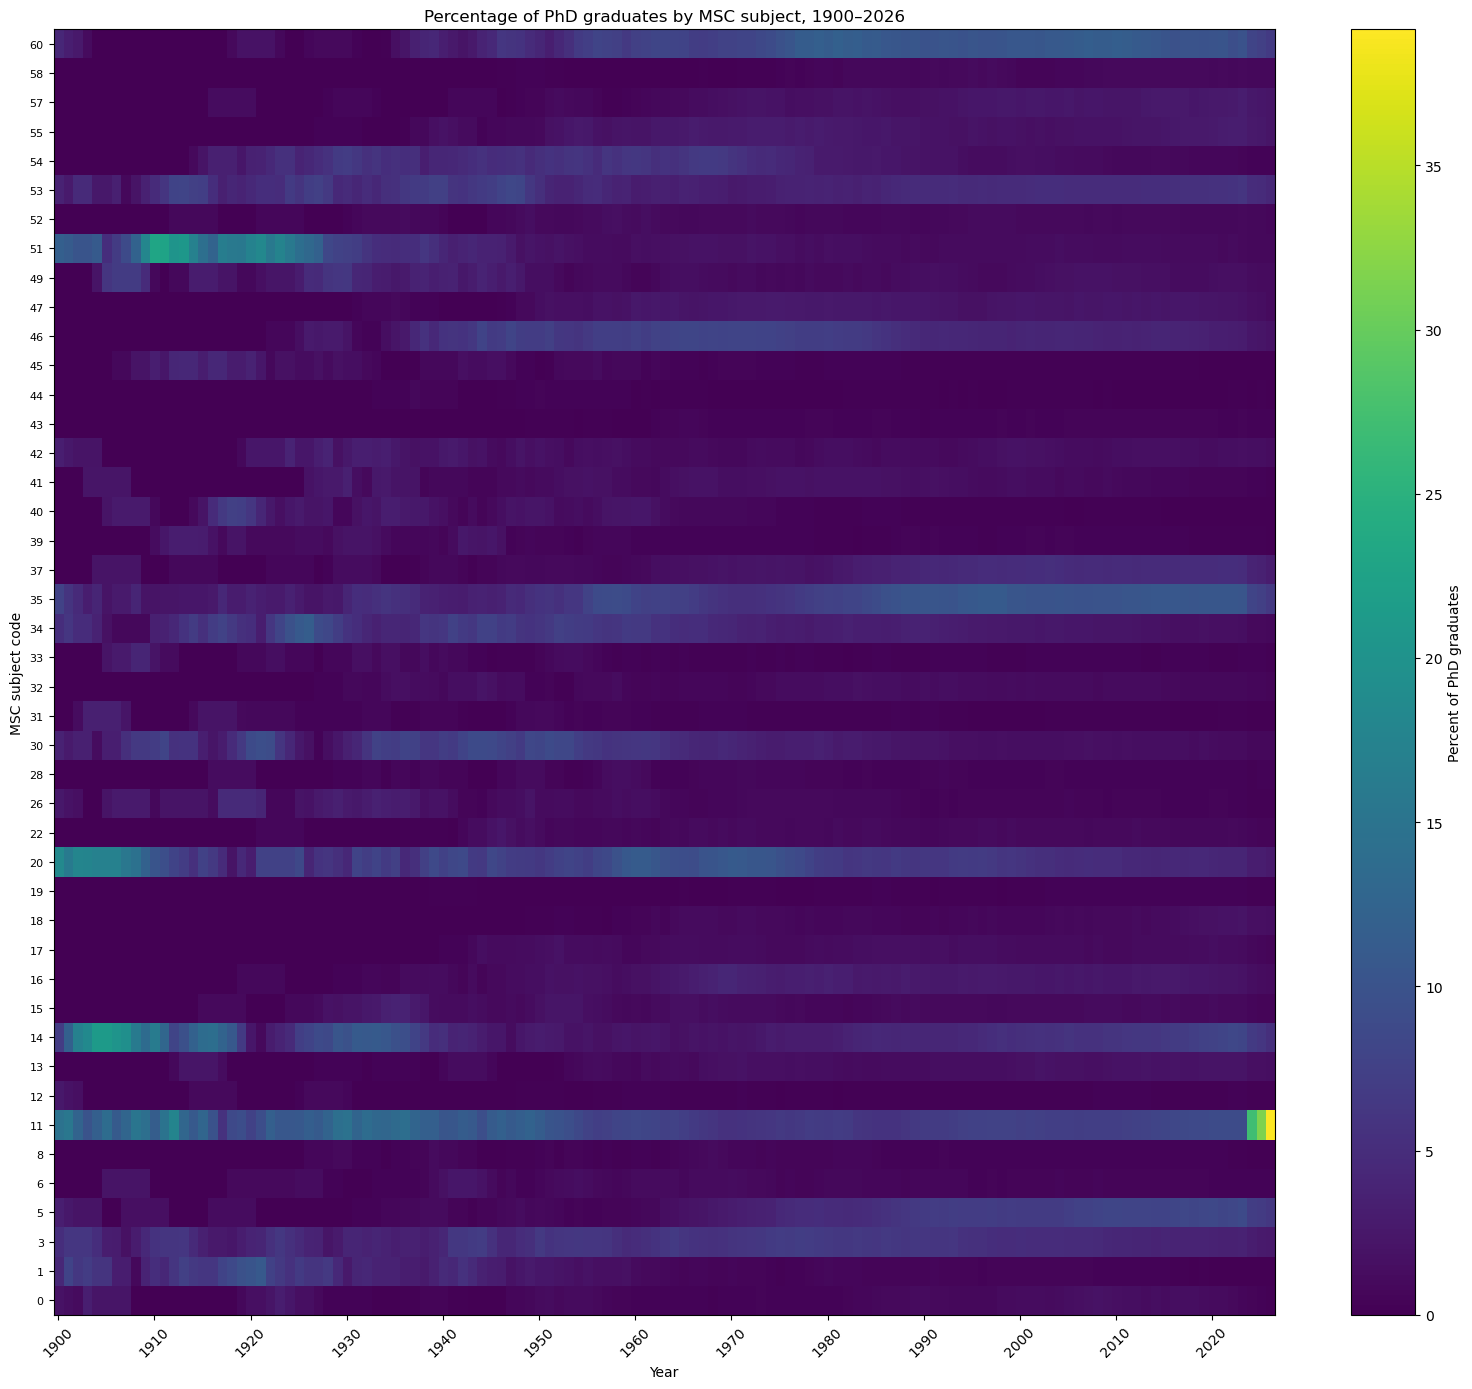

In [25]:
share_smooth = share.T.rolling(5, center=True, min_periods=1).mean().T

fig, ax = plt.subplots(figsize=(16, 14))

im = ax.imshow(
    share_smooth,
    aspect="auto",
    origin="lower",
    interpolation="nearest"
)

ax.set_xticks(np.arange(0, len(years), 10))
ax.set_xticklabels(years[::10], rotation=45)

ax.set_yticks(np.arange(len(codes_pure)))
ax.set_yticklabels([str(int(c)) for c in codes_pure], fontsize=8)

ax.set_xlabel("Year")
ax.set_ylabel("MSC subject code")
ax.set_title("Percentage of PhD graduates by MSC subject, 1900–2026")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Percent of PhD graduates")

plt.tight_layout()
plt.show()

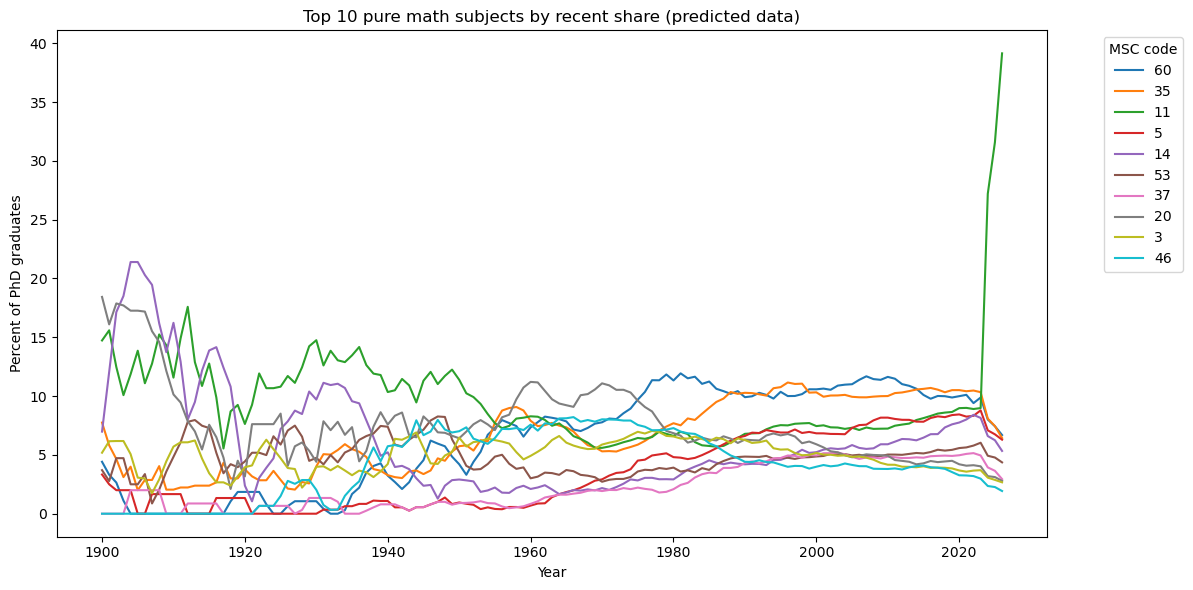

In [26]:
top10 = share.loc[:, 2000:2025].mean(axis=1).sort_values(ascending=False).head(10).index

share_top10 = share.loc[top10].T
share_top10_smooth = share_top10.rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))

for code_pure in top10:
    ax.plot(
        share_top10_smooth.index,
        share_top10_smooth[code_pure],
        label=str(int(code_pure))
    )

ax.set_xlabel("Year")
ax.set_ylabel("Percent of PhD graduates")
ax.set_title("Top 10 pure math subjects by recent share (predicted data)")
ax.legend(title="MSC code", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [27]:
top10

Index([60.0, 35.0, 11.0, 5.0, 14.0, 53.0, 37.0, 20.0, 3.0, 46.0], dtype='float64', name='subject_code')

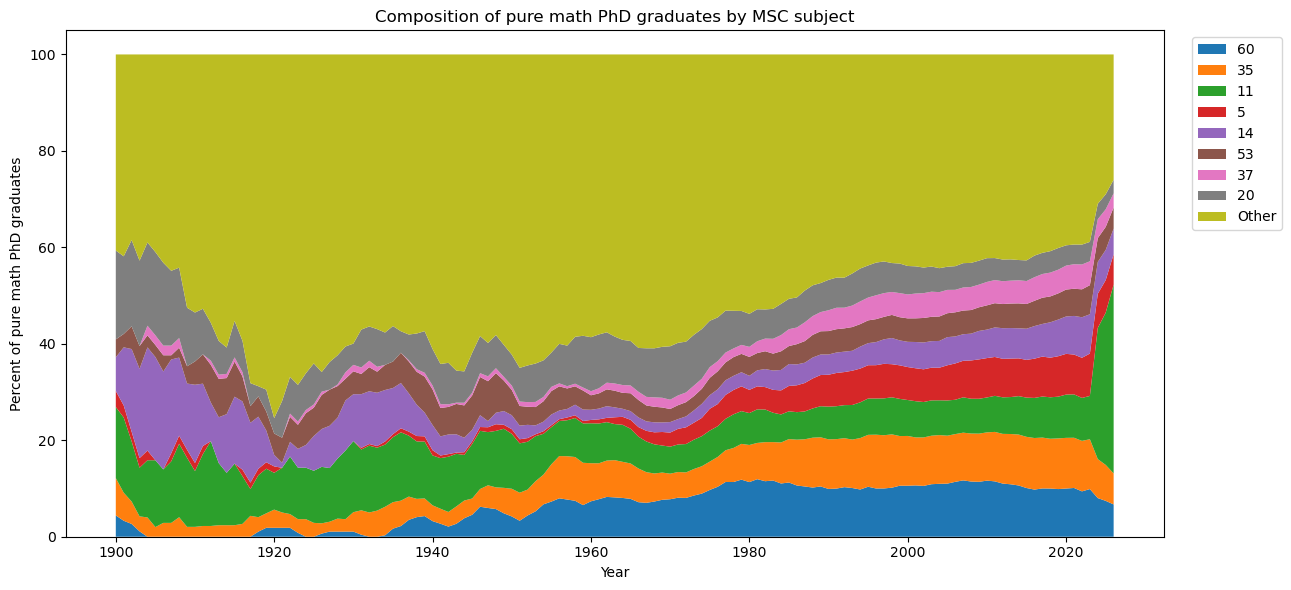

In [28]:
top8 = share.loc[:, 2000:2025].mean(axis=1).sort_values(ascending=False).head(8).index

area_data = share.loc[top8].T.copy()
area_data["Other"] = 100 - area_data.sum(axis=1)

area_data_smooth = area_data.rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 6))

ax.stackplot(
    area_data_smooth.index,
    area_data_smooth.T,
    labels=[str(int(c)) if c != "Other" else "Other" for c in area_data_smooth.columns]
)

ax.set_xlabel("Year")
ax.set_ylabel("Percent of pure math PhD graduates")
ax.set_title("Composition of pure math PhD graduates by MSC subject")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

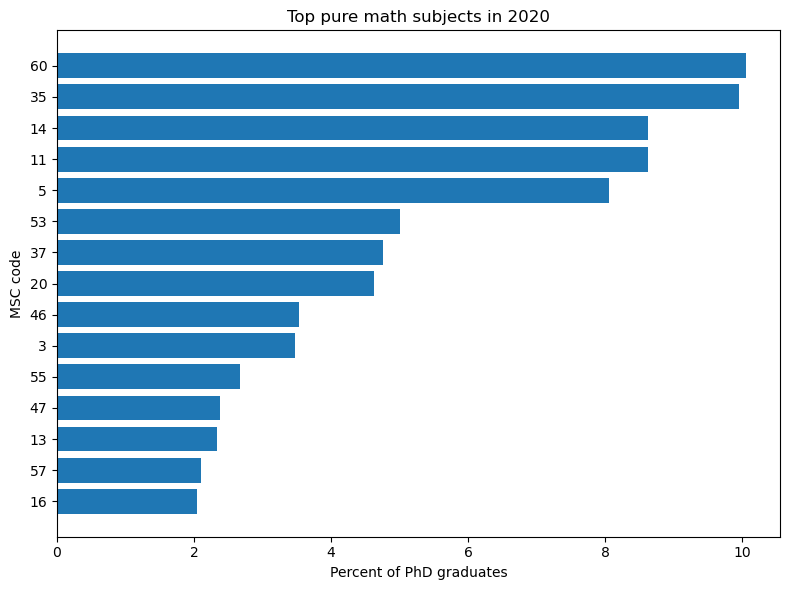

In [29]:
year = 2020

top_year = share[year].sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh([str(int(c)) for c in top_year.index[::-1]], top_year.values[::-1])

ax.set_xlabel("Percent of PhD graduates")
ax.set_ylabel("MSC code")
ax.set_title(f"Top pure math subjects in {year}")

plt.tight_layout()
plt.show()

### 2. compare with original data (data-new.json)

In [30]:
#create DataFrame with subject_code given from mgp
nodes_0=nodes[(~nodes['subject_code'].isna())&(nodes['predicted_subject_code'].isna())]
len(nodes_0)

202492

In [31]:
years = np.arange(1900, 2027)

valid_0_pure = nodes_0[
    (nodes_0["subject_code"].notna()) &
    (nodes_0["subject_code"]<61) &
    (nodes_0["year"].between(1900, 2026))
].copy()


valid_0_pure["year"] = valid_0_pure["year"].astype(int)

codes_0_pure = np.sort(valid_0_pure["subject_code"].unique())

counts = pd.crosstab(
    valid_0_pure["subject_code"],
    valid_0_pure["year"]
).reindex(index=codes_0_pure, columns=years, fill_value=0)

year_totals = counts.sum(axis=0).replace(0, np.nan)

share = counts.div(year_totals, axis=1) * 100

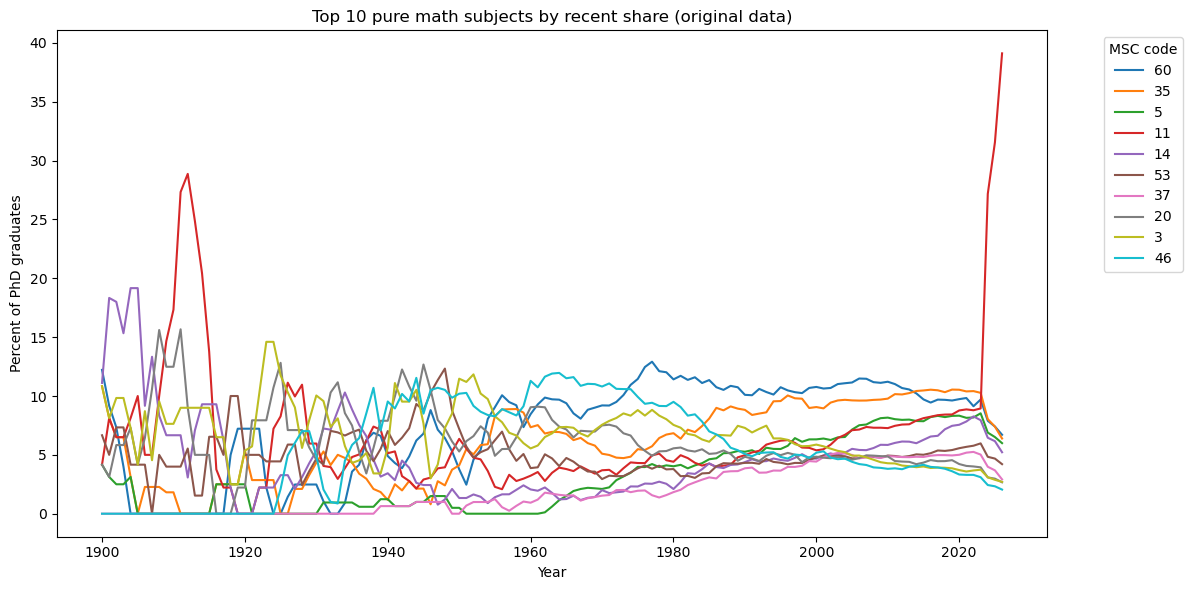

In [32]:
top10 = share.loc[:, 2000:2025].mean(axis=1).sort_values(ascending=False).head(10).index

share_top10 = share.loc[top10].T
share_top10_smooth = share_top10.rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))

for code in top10:
    ax.plot(
        share_top10_smooth.index,
        share_top10_smooth[code],
        label=str(int(code))
    )

ax.set_xlabel("Year")
ax.set_ylabel("Percent of PhD graduates")
ax.set_title("Top 10 pure math subjects by recent share (original data)")
ax.legend(title="MSC code", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [33]:
top10

Index([60.0, 35.0, 5.0, 11.0, 14.0, 53.0, 37.0, 20.0, 3.0, 46.0], dtype='float64', name='subject_code')

### 3. Precentage of subjects applied math (subject code $\ge$ 62)

In [34]:
#applied math count
len(nodes[(nodes["subject_code"]>61)&(nodes["subject_code"].notna())&(nodes["year"].between(1900, 2026))])

142294

In [35]:
years = np.arange(1900, 2027)

valid_applied = nodes[
    (nodes["subject_code"].notna()) &
    (nodes["subject_code"]>61) &
    (nodes["year"].between(1900, 2026))
].copy()

valid_applied["year"] = valid_applied["year"].astype(int)

codes_applied = np.sort(valid_applied["subject_code"].unique())

counts = pd.crosstab(
    valid_applied["subject_code"],
    valid_applied["year"]
).reindex(index=codes_applied, columns=years, fill_value=0)

year_totals = counts.sum(axis=0).replace(0, np.nan)

share = counts.div(year_totals, axis=1) * 100


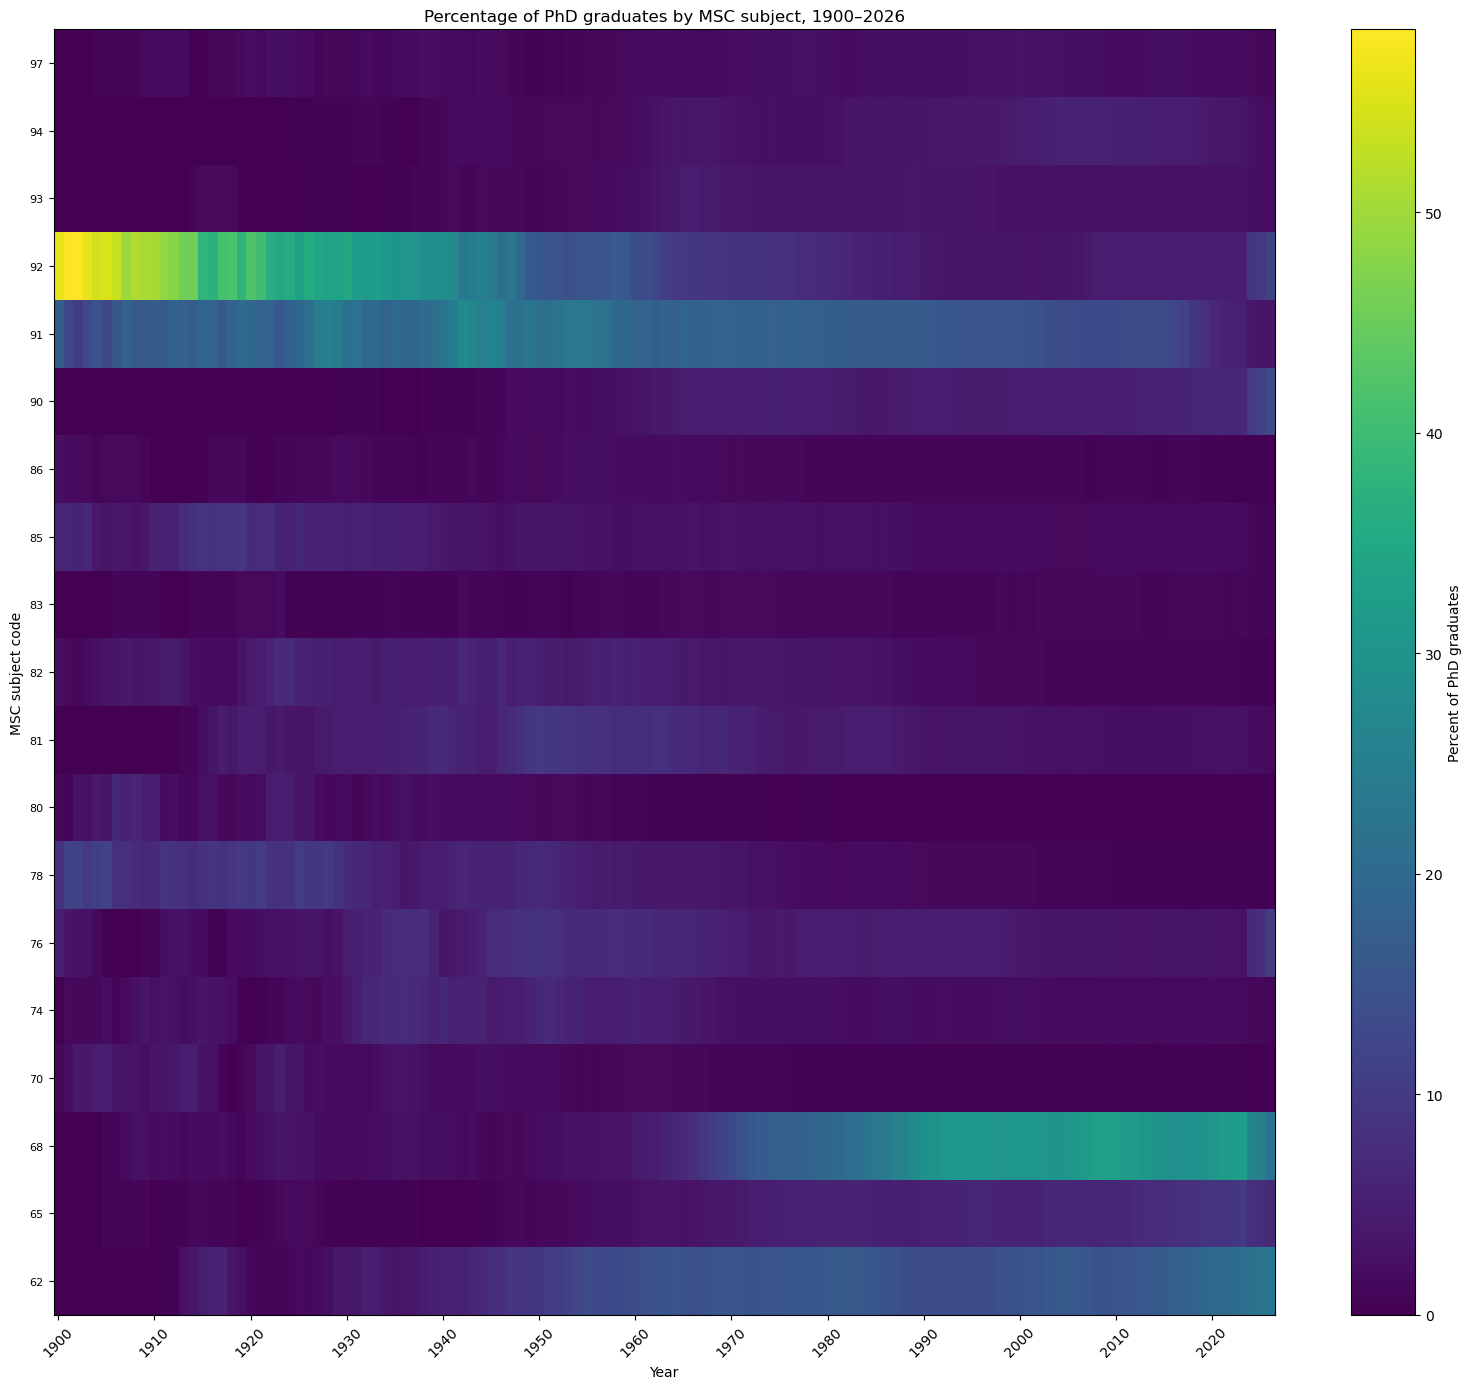

In [36]:
share_smooth = share.T.rolling(5, center=True, min_periods=1).mean().T

fig, ax = plt.subplots(figsize=(16, 14))

im = ax.imshow(
    share_smooth,
    aspect="auto",
    origin="lower",
    interpolation="nearest"
)

ax.set_xticks(np.arange(0, len(years), 10))
ax.set_xticklabels(years[::10], rotation=45)

ax.set_yticks(np.arange(len(codes_applied)))
ax.set_yticklabels([str(int(c)) for c in codes_applied], fontsize=8)

ax.set_xlabel("Year")
ax.set_ylabel("MSC subject code")
ax.set_title("Percentage of PhD graduates by MSC subject, 1900–2026")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Percent of PhD graduates")

plt.tight_layout()
plt.show()

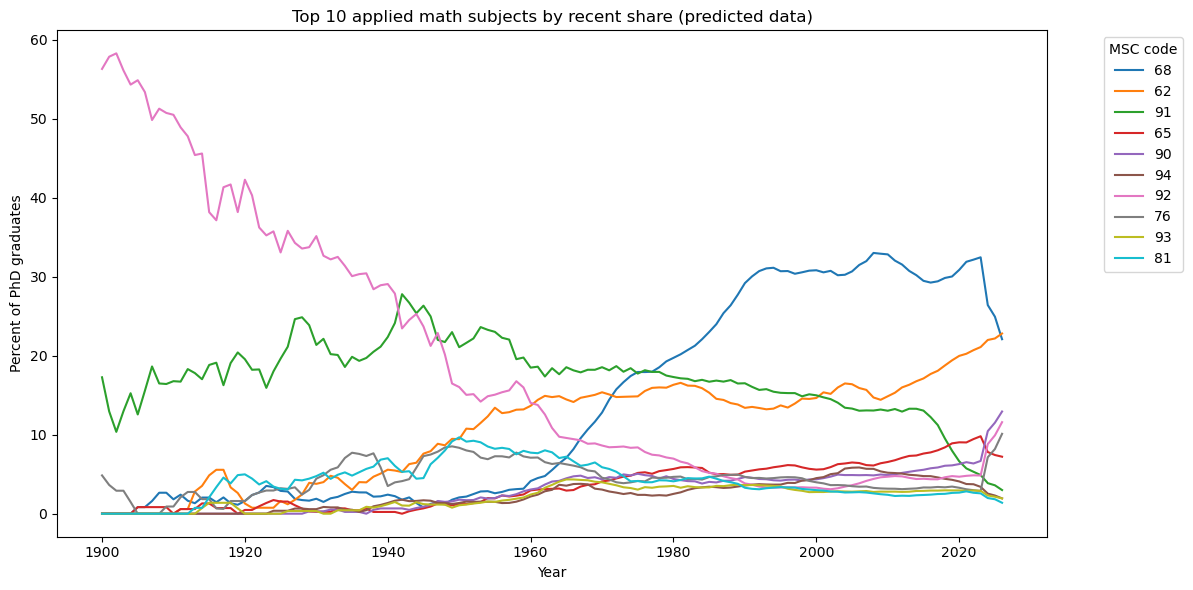

In [37]:
top10 = share.loc[:, 2000:2025].mean(axis=1).sort_values(ascending=False).head(10).index

share_top10 = share.loc[top10].T
share_top10_smooth = share_top10.rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))

for code in top10:
    ax.plot(
        share_top10_smooth.index,
        share_top10_smooth[code],
        label=str(int(code))
    )

ax.set_xlabel("Year")
ax.set_ylabel("Percent of PhD graduates")
ax.set_title("Top 10 applied math subjects by recent share (predicted data)")
ax.legend(title="MSC code", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

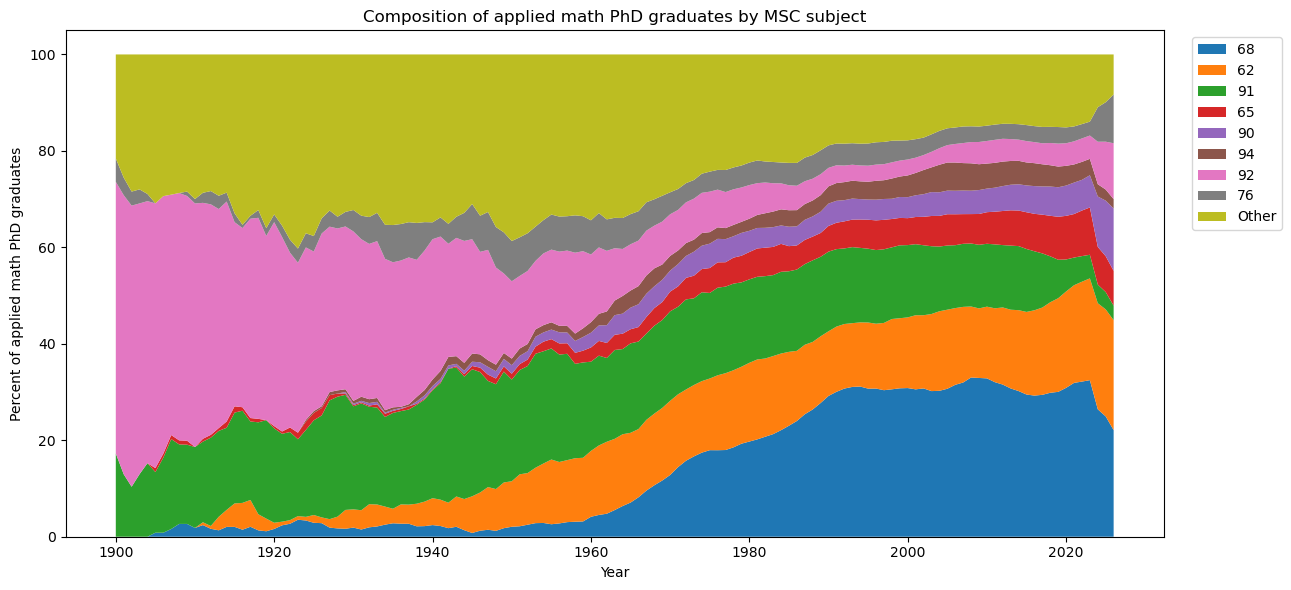

In [38]:
top8 = share.loc[:, 2000:2025].mean(axis=1).sort_values(ascending=False).head(8).index

area_data = share.loc[top8].T.copy()
area_data["Other"] = 100 - area_data.sum(axis=1)

area_data_smooth = area_data.rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 6))

ax.stackplot(
    area_data_smooth.index,
    area_data_smooth.T,
    labels=[str(int(c)) if c != "Other" else "Other" for c in area_data_smooth.columns]
)

ax.set_xlabel("Year")
ax.set_ylabel("Percent of applied math PhD graduates")
ax.set_title("Composition of applied math PhD graduates by MSC subject")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

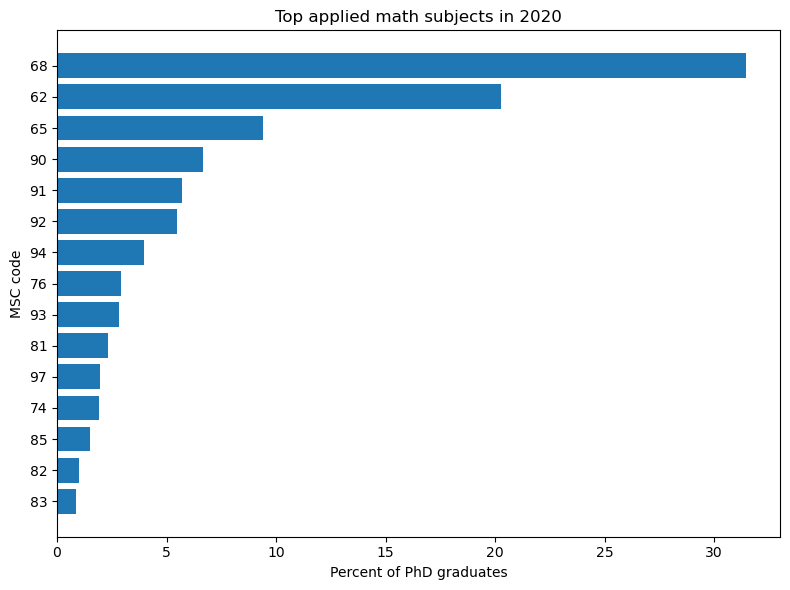

In [39]:
year = 2020

top_year = share[year].sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh([str(int(c)) for c in top_year.index[::-1]], top_year.values[::-1])

ax.set_xlabel("Percent of PhD graduates")
ax.set_ylabel("MSC code")
ax.set_title(f"Top applied math subjects in {year}")

plt.tight_layout()
plt.show()


We find for both pure and applied math, subject precentages changed drastically before 1960, and stablizes after 1960. This may due to the low number of Ph.D. students before 1960. Some sharp behavior near the final years should be interpreted cautiously because recent MGP data may be incomplete.

### Pure Math

The top pure math subjects by recent average share, using the augmented dataset, are:

```text
60, 35, 11, 05, 14, 53, 37, 20, 03, 46
```
which are Probability, PDE, number theory, combinatorics, algebraic geometry,differential geometry, dynamical systems, group theory, mathematical logic, and functional analysis/operator theory.

The corresponding analysis using `data-new.json` gives a very similar top 10 list:

```text
60, 35, 05, 11, 14, 53, 37, 20, 03, 46
```

This suggests that the high-confidence subject imputation does not substantially change the identity of the leading recent pure math subjects.


The heatmap plot and stacked area chart show that several subjects rises in later 20th century: 60, 35, 03, 05; while the relative dominance of some early twentieth-century areas declines: 20, 51, 14, and some subjects are relatively stable: 11, 53. 

### Applied Math

The top applied math subjects by recent average share are:

```text
68, 62, 91, 65, 90, 94, 92, 76, 93, 81
```

The applied math distribution is dominated in recent decades by 68-computer science and 62-statistics. Code 68 rises strongly in the late twentieth century and becomes the largest applied subject by 2020. Code 62 is also a major recent category. Earlier in the twentieth century, the applied distribution is more heavily influenced by other applied categories, including code 91 and 92.

The stacked area chart suggests a broad shift in applied mathematics from older applied/natural science categories toward statistics, computer science, numerical analysis, operations research, and related modern applied fields.
